In [97]:
!pip install pyotp
!pip install mplfinance
!pip install pandas_ta
!pip install fyers_apiv3

In [98]:
import requests
import base64
from datetime import datetime, timedelta, date
from datetime import time as dt_time
import time
import threading
import pyotp
from pytz import timezone
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import mplfinance as mpf
import pandas_ta as ta
import pygame
import os
import pytz
import json
import re

from IPython.display import display, clear_output

from fyers_apiv3 import fyersModel
from fyers_apiv3.FyersWebsocket import data_ws

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback, ModelCheckpoint
from scipy.signal import argrelextrema
import tensorflow as tf

In [99]:
def get_index_symbol_and_quantity(index):

    # Dictionary mapping index name to index symbols
    index_symbols = {
        'Bankex': 'BSE:BANKEX-INDEX',
        'Finnifty': 'NSE:FINNIFTY-INDEX',
        'Bank Nifty': 'NSE:NIFTYBANK-INDEX',
        'Nifty': 'NSE:NIFTY50-INDEX',
        'Sensex': 'BSE:SENSEX-INDEX'
    }

    # Determine the index symbol for the given index
    index_symbol = index_symbols.get(index, 'Invalid Index')

    # Determine the quantity based on the index symbol
    if index_symbol == "NSE:NIFTY50-INDEX":
        quantity = 25  # 25 is one lot for Nifty
    elif index_symbol == "NSE:NIFTYBANK-INDEX":
        quantity = 15  # 15 is one lot for Bank Nifty
    elif index_symbol == "NSE:FINNIFTY-INDEX":
        quantity = 40  # 40 is one lot for Finnifty
    elif index_symbol == "BSE:SENSEX-INDEX":
        quantity = 20  # 20 is two lot for Sensex
    elif index_symbol == "BSE:BANKEX-INDEX":
        quantity = 15  # 15 is one lot for Bankex
    else:
        quantity = 0  # Default value if none of the conditions match

    return index_symbol, quantity

In [100]:
app_id = "TS79V3NXK1-100"
secret_key = "KQCPB0FJ74"
redirect_uri = "https://google.com"
fyers_user = "XM22383"
fyers_pin = "4628"
fyers_totp = "EAQD6K4IUYOEGPJNVE6BMPTUSDCWIOHW"
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"

fyers = None
fyers_socket = None

index_symbol, quantity = get_index_symbol_and_quantity("Bank Nifty")

interval_minutes = 5 # Set the interval to 1, 5, or 15 minutes

ist_timezone = pytz.timezone("Asia/Kolkata")

#Variables
ce_ltp = 0
pe_ltp = 0
index_ltp = 0
buy_sell_checked = False
ce_strike = None
pe_strike = None
ce_symbol = None
pe_symbol = None

target = 80
trailing_sl = 40

brokerage = 100

fixed_ltp = 0
fixed_index_ltp = 0
prev_ltp = 0
target_inside = 0
target_index_inside = 0
trailing_sl_inside = 0
trailing_index_inside = 0

active_order = False

sl_hit_condition = False
total_loss = 0
total_profit = 0
overall_win = 0
overall_loss = 0
total_points = 0

unsubscribe_done = False

active_order_sleep = 1

In [101]:
session = fyersModel.SessionModel(
    client_id=app_id,
    secret_key=secret_key,
    redirect_uri=redirect_uri,
    response_type=response_type,
    grant_type=grant_type
)

def getEncodedString(string):
    string = str(string)
    base64_bytes = base64.b64encode(string.encode("ascii"))
    return base64_bytes.decode("ascii")

if session is not None:
    session.generate_authcode()

    url_send_login_otp = "https://api-t2.fyers.in/vagator/v2/send_login_otp_v2"
    res = requests.post(url=url_send_login_otp, json={"fy_id": getEncodedString(fyers_user), "app_id": "2"}).json()

    if datetime.now().second % 30 > 27:
        time.sleep(5)

    url_verify_otp = "https://api-t2.fyers.in/vagator/v2/verify_otp"
    res2 = requests.post(url=url_verify_otp, json={"request_key": res["request_key"], "otp": pyotp.TOTP(fyers_totp).now()}).json()

    ses = requests.Session()
    url_verify_otp2 = "https://api-t2.fyers.in/vagator/v2/verify_pin_v2"
    payload2 = {"request_key": res2["request_key"], "identity_type": "pin", "identifier": getEncodedString(fyers_pin)}
    res3 = ses.post(url=url_verify_otp2, json=payload2).json()

    ses.headers.update({'authorization': f"Bearer {res3['data']['access_token']}"})

    tokenurl = "https://api-t1.fyers.in/api/v3/token"
    payload3 = {
        "fyers_id": fyers_user,
        "app_id": app_id[:-4],
        "redirect_uri": redirect_uri,
        "appType": "100",
        "code_challenge": "",
        "state": "None",
        "scope": "",
        "nonce": "",
        "response_type": "code",
        "create_cookie": True
    }

    res3 = ses.post(url=tokenurl, json=payload3).json()

    url = res3['Url']
    parsed = urlparse(url)
    auth_code = parse_qs(parsed.query)['auth_code'][0]

    session.set_token(auth_code)

    auth_response = session.generate_token()
    access_token = auth_response["access_token"]

    fyers = fyersModel.FyersModel(client_id=app_id, token=access_token)

    ws_token = app_id + ":" + access_token
    fyers_socket = data_ws.FyersDataSocket(access_token=ws_token, log_path="")

pd.DataFrame(fyers.get_profile())

,s,code,message,data
fy_id,ok,200,,XM22383
name,ok,200,,MARSHAL TUDU
image,ok,200,,https://myaccount-docs-prod.fyers.in/Profile_P...
display_name,ok,200,,None
pin_change_date,ok,200,,25-09-2023 17:16:16
email_id,ok,200,,iammarshal22@gmail.com
pwd_change_date,ok,200,,01-06-2022 20:36:31
PAN,ok,200,,---------
mobile_number,ok,200,,8458060663
totp,ok,200,,True


In [102]:
def fetch_candle_data(number):
    while True:
        try:
            today = date.today()
            yesterday = today - timedelta(number)

            data = {
                "symbol": index_symbol,
                "resolution": interval_minutes,
                "date_format": "1",
                "range_from": yesterday,
                "range_to": today,
                "cont_flag": "1"
            }

            result = fyers.history(data=data)

            if result is not None:
                return result
        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [103]:
def fetch_train_candle_data(days_count):
    train_df = pd.DataFrame()

    while True:
        try:
            date_increment = 100
            for i in range(days_count):
                today = date.today() - timedelta(date_increment)
                yesterday = today - timedelta(100)

                data = {
                    "symbol": index_symbol,
                    "resolution": interval_minutes,
                    "date_format": "1",
                    "range_from": yesterday,
                    "range_to": today,
                    "cont_flag": "1"
                }

                result = fyers.history(data=data)

                if result is not None:
                    temp_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                    train_df = pd.concat([temp_df, train_df], ignore_index=True)

                date_increment += 100

            if train_df is not None:
                return train_df

        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [104]:
def find_local_extrema(df):
    order=5
    atr_multiplier=1.5
    min_distance=5

    # Find local maxima and minima
    local_max = argrelextrema(df['high'].values, np.greater_equal, order=order)[0]
    local_min = argrelextrema(df['low'].values, np.less_equal, order=order)[0]

    # Calculate the threshold based on ATR
    threshold = df['ATR_14'] * atr_multiplier

    # Filter by significance
    significant_max = []
    significant_min = []

    for idx in local_max:
        if idx > order and idx < len(df) - order:
            high = df['high'].iloc[idx]
            if significant_min:
                low = df['low'].iloc[significant_min[-1]]
                if (high - low) > threshold.iloc[idx]:
                    significant_max.append(idx)
            else:
                significant_max.append(idx)

    for idx in local_min:
        if idx > order and idx < len(df) - order:
            low = df['low'].iloc[idx]
            if significant_max:
                high = df['high'].iloc[significant_max[-1]]
                if (high - low) > threshold.iloc[idx]:
                    significant_min.append(idx)
            else:
                significant_min.append(idx)

    # Ensure minimum distance
    def filter_by_distance(points, min_distance):
        filtered_points = []
        for i in range(len(points)):
            if not filtered_points or (points[i] - filtered_points[-1]) > min_distance:
                filtered_points.append(points[i])
        return filtered_points

    significant_max = filter_by_distance(significant_max, min_distance)
    significant_min = filter_by_distance(significant_min, min_distance)

    return significant_max, significant_min

In [105]:
def label_signals(df):
    df['Signal'] = 0
    df['Entry Price'] = 0.0
    df['Exit Price'] = 0.0

    for i in range(len(df)):
        entry_price = df['close'].iloc[i]

        target = df['Target'].iloc[i]
        stop_loss = df['Stop Loss'].iloc[i]

        #target = 100
        #stop_loss = 50

        buy_target_price = entry_price + target
        buy_sl_price = entry_price - stop_loss

        sell_target_price = entry_price - target
        sell_sl_price = entry_price + stop_loss

        future_data = df.iloc[i + 1:]

        # Check for buy signal
        for j in range(len(future_data)):
            future_high = future_data['high'].iloc[j]
            future_low = future_data['low'].iloc[j]

            if future_high >= buy_target_price:
                df.at[df.index[i], 'Signal'] = 2 # Buy Signal
                df.at[df.index[i], 'Entry Price'] = entry_price
                df.at[df.index[i], 'Exit Price'] = future_high
                break
            elif future_low <= buy_sl_price:
                break

        # Check for sell signal
        for j in range(len(future_data)):
            future_high = future_data['high'].iloc[j]
            future_low = future_data['low'].iloc[j]

            if future_low <= sell_target_price:
                df.at[df.index[i], 'Signal'] = 1 # Sell Signal
                df.at[df.index[i], 'Entry Price'] = entry_price
                df.at[df.index[i], 'Exit Price'] = future_low
                break
            elif future_high >= sell_sl_price:
                break

    return df

In [106]:
ist = timezone('Asia/Kolkata')

def process_df_with_features(df):
    df['datetime'] = pd.to_datetime(df['datetime'], unit='s')

    df['datetime'] = df['datetime'].dt.tz_localize('UTC').dt.tz_convert(ist).dt.tz_localize(None)

    df.set_index(df['datetime'], inplace=True)

    df.drop('datetime', axis=1, inplace=True)
    df.drop('volume', axis=1, inplace=True)

    #mom_length = [1, 5, 14]
    #for length in mom_length:
        #df[f"mom_{length}"] = ta.mom(df['close'], length=length)

    #df['hour_of_day'] = df.index.hour
    #df['day_of_week'] = df.index.dayofweek

    #df['high_low_range'] = df['high'] - df['low']
    #df['open_close_range'] = df['open'] - df['close']

    lengths = [14]

    #for length in lengths:
        #df[f'EMA_{length}'] = ta.ema(df['close'], length=length)

    #for length in [14]:
        #df[f'RSI_{length}'] = ta.rsi(df['close'], length=length)

    for length in lengths:
        df[f'ATR_{length}'] = ta.atr(df['high'], df['low'], df['close'], length=length)

    df['Target'] = df['ATR_14'] * 2
    df['Stop Loss'] = df['ATR_14']

    #cdl_pattern_df = df.ta.cdl_pattern(name='all')
    #df = pd.concat([df, cdl_pattern_df], axis=1)

    df = df.round(2)

    df.dropna(inplace=True)

    return df

In [109]:
#train_candles = fetch_candle_data(100)

#train_df = pd.DataFrame(train_candles['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])

train_df = fetch_train_candle_data(25)

print(len(train_df))

train_df = train_df.drop_duplicates(subset='datetime', keep='first')

print(len(train_df))

127820
126695


In [110]:
train_df = process_df_with_features(train_df)
train_df = label_signals(train_df)
train_df

,open,high,low,close,ATR_14,Target,Stop Loss,Signal,Entry Price,Exit Price
datetime,,,,,,,,,,
2017-09-28 10:20:00,23831.20,23845.30,23818.80,23843.80,42.99,85.97,42.99,1,23843.8,23718.8
2017-09-28 10:25:00,23843.80,23865.60,23834.10,23858.10,41.76,83.53,41.76,1,23858.1,23760.2
2017-09-28 10:30:00,23858.30,23858.40,23829.40,23829.40,40.45,80.90,40.45,0,0.0,0.0
2017-09-28 10:35:00,23829.40,23847.20,23824.30,23842.60,38.70,77.40,38.70,1,23842.6,23760.2
2017-09-28 10:40:00,23840.70,23856.10,23826.80,23851.40,37.79,75.58,37.79,1,23851.4,23760.2
...,...,...,...,...,...,...,...,...,...,...
2024-08-02 15:05:00,51355.15,51394.45,51343.25,51346.10,54.09,108.18,54.09,0,0.0,0.0
2024-08-02 15:10:00,51348.85,51351.80,51316.75,51341.70,52.73,105.46,52.73,0,0.0,0.0
2024-08-02 15:15:00,51342.10,51368.75,51325.35,51349.85,52.06,104.13,52.06,0,0.0,0.0


In [111]:
train_df = train_df[[col for col in train_df.columns if col not in ['Entry Price', 'Exit Price']]]

In [112]:
X_cl = train_df[[col for col in train_df.columns if col != 'Signal']]

y_cl = train_df['Signal']

#cl_X_train, cl_X_test, cl_y_train, cl_y_test = train_test_split(X_cl, y_cl, test_size=0.2, random_state=42)

# Split the data in sequence
test_size_cl = int(len(X_cl) * 0.2)  # 20% of the data for testing/validation
cl_X_train, cl_X_test = X_cl[:-test_size_cl], X_cl[-test_size_cl:]
cl_y_train, cl_y_test = y_cl[:-test_size_cl], y_cl[-test_size_cl:]

In [113]:
# Initialize and train the classifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(cl_X_train, cl_y_train)

# Make predictions
y_pred_rf = rf_model.predict(cl_X_test)

# Evaluate the model
print("Random Forest Accuracy: {:.2f}%".format(accuracy_score(cl_y_test, y_pred_rf) * 100))
print(classification_report(cl_y_test, y_pred_rf, target_names=['hold', 'sell', 'buy']))

Random Forest Accuracy: 33.19%
              precision    recall  f1-score   support

        hold       0.33      0.22      0.27      8236
        sell       0.32      0.71      0.45      8195
         buy       0.40      0.08      0.14      8905

    accuracy                           0.33     25336
   macro avg       0.35      0.34      0.28     25336
weighted avg       0.35      0.33      0.28     25336



In [114]:
def sanitize_filename(filename):
    # Define a regex pattern for allowed characters (alphanumeric and some special characters)
    pattern = re.compile(r'[^a-zA-Z0-9_.-]')
    # Replace any character not matching the pattern with an underscore
    sanitized_filename = pattern.sub('_', filename)
    return sanitized_filename

In [115]:
# Function to check if the file is from the past week
def is_file_from_past_week(filepath):
    if not os.path.exists(filepath):
        return False
    file_mod_time = datetime.fromtimestamp(os.path.getmtime(filepath))
    return file_mod_time.date() >= (datetime.today().date() - timedelta(days=7))

In [116]:
class PlotLosses(Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []

        # Apply dark background style to Matplotlib
        plt.style.use('dark_background')

        self.fig = plt.figure()

        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.i += 1

        # Clear previous plot and plot new data
        clear_output(wait=True)

        plt.figure(figsize=(14, 7))

        plt.plot(self.x, self.losses, label="Training Loss", color='white')
        plt.plot(self.x, self.val_losses, label="Validation Loss", color=(0.95, 0.38, 0.25, 1))
        plt.legend()
        plt.title('Training Loss vs. Validation Loss', color='white')
        plt.xlabel('Epoch', color='white')
        plt.ylabel('Loss', color='white')

        # Customize tick colors
        plt.tick_params(colors='white')

        plt.grid(False)

        plt.show()

In [117]:
# Prepare the data for regression
def preprocess_regression_data(df, sequence_length):
    # Initialize individual scalers for each feature
    regression_scalers = {}
    for column in df.columns:
        regression_scalers[column] = MinMaxScaler()
        df[column] = regression_scalers[column].fit_transform(df[column].values.reshape(-1, 1))

    X, y = [], []
    for i in range(sequence_length, len(df)):
        X.append(df.iloc[i-sequence_length:i].values)
        y.append(df.iloc[i, df.columns.get_loc('close')])  # Assuming 'close' is always the target

    X, y = np.array(X), np.array(y)

    return X, y, regression_scalers

sequence_length = 5

X_reg, y_reg, regression_scalers = preprocess_regression_data(train_df.copy(), sequence_length)

# Split the data into training and testing sets
test_size_reg = int(len(X_reg) * 0.2)  # 20% of the data for testing/validation
X_train_reg, X_test_reg = X_reg[:-test_size_reg], X_reg[-test_size_reg:]
y_train_reg, y_test_reg = y_reg[:-test_size_reg], y_reg[-test_size_reg:]

In [118]:
# Train a linear regression model
lr_reg_model = LinearRegression()
lr_reg_model.fit(X_train_reg.reshape(X_train_reg.shape[0], -1), y_train_reg)

# Make predictions
y_pred_lr_reg = lr_reg_model.predict(X_test_reg.reshape(X_test_reg.shape[0], -1))

# Evaluate the model
mse_lr_reg = mean_squared_error(y_test_reg, y_pred_lr_reg)
print(f"Linear Regression MSE: {mse_lr_reg}")

Linear Regression MSE: 1.6552334498675067e-06


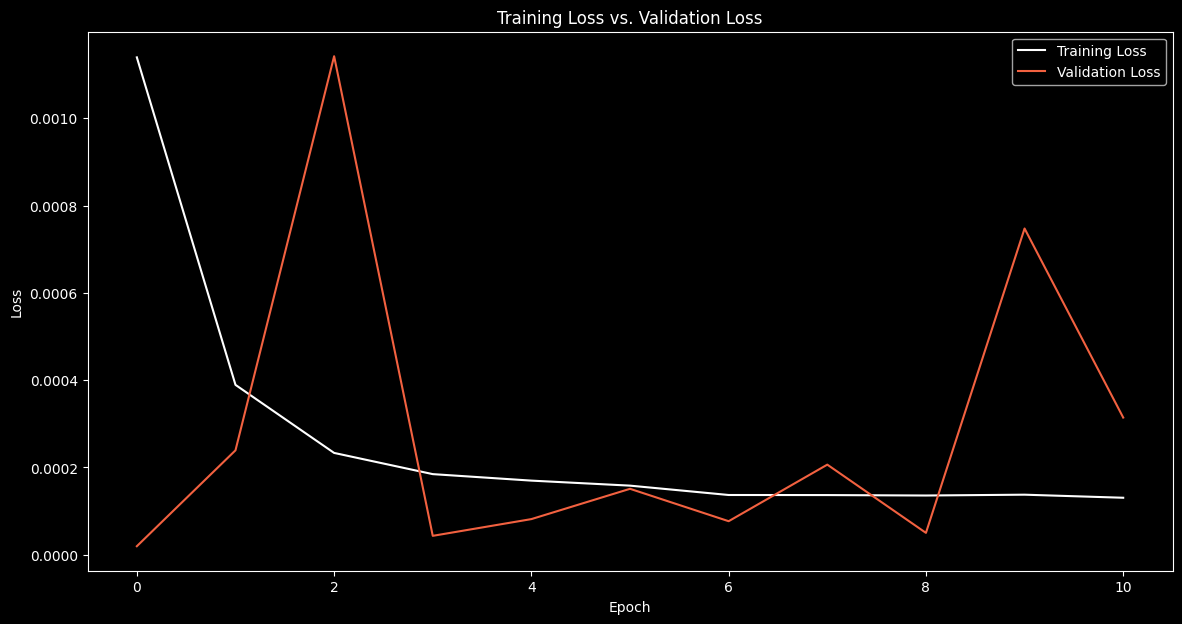

1584/1584 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 1.2991e-04 - val_loss: 3.1429e-04 - learning_rate: 5.0000e-04
Trained and saved a new LSTM regression model.
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Regression Model MSE: 1.9468696982609425e-05


In [119]:
def build_bidirectional_lstm_attention_model_regression(input_shape):
    inputs = Input(shape=input_shape)

    # First LSTM Layer
    lstm = LSTM(512, return_sequences=True)(inputs)
    attention = Attention()([lstm, lstm])
    x = Dropout(0.3)(attention)

    # Second LSTM Layer
    x = LSTM(256, return_sequences=True)(x)
    x = Dropout(0.3)(x)

    # Third LSTM Layer
    x = LSTM(128, return_sequences=False)(x)
    x = Dropout(0.3)(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    return model

# LSTM regression model
lstm_reg_filename = f'lstm_reg_model_{index_symbol}_{interval_minutes}.keras'
sanitized_lstm_reg_filename = sanitize_filename(lstm_reg_filename)
lstm_reg_model_path = f'models/{sanitized_lstm_reg_filename}'

if os.path.exists(lstm_reg_model_path) and is_file_from_past_week(lstm_reg_model_path):
    lstm_reg_model = load_model(lstm_reg_model_path)
    print("Loaded existing LSTM regression model.")
else:
    input_shape = (X_train_reg.shape[1], X_train_reg.shape[2])
    lstm_reg_model = build_bidirectional_lstm_attention_model_regression(input_shape)
    lstm_reg_model.compile(optimizer='adam', loss='mean_squared_error')

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
    checkpoint = ModelCheckpoint(lstm_reg_model_path, monitor='val_loss', save_best_only=True, save_weights_only=False, mode='min')

    lstm_reg_model.fit(
        X_train_reg, y_train_reg,
        validation_data=(X_test_reg, y_test_reg),
        epochs=100,
        batch_size=64,
        callbacks=[early_stopping, reduce_lr, checkpoint, PlotLosses()],
        verbose=1
    )
    print("Trained and saved a new LSTM regression model.")

# Make predictions for regression
y_pred_lstm_reg = lstm_reg_model.predict(X_test_reg)
y_pred_lstm_reg = np.squeeze(y_pred_lstm_reg)

# Evaluate the regression model
mse_lstm_reg = mean_squared_error(y_test_reg, y_pred_lstm_reg)
print(f'Regression Model MSE: {mse_lstm_reg}')

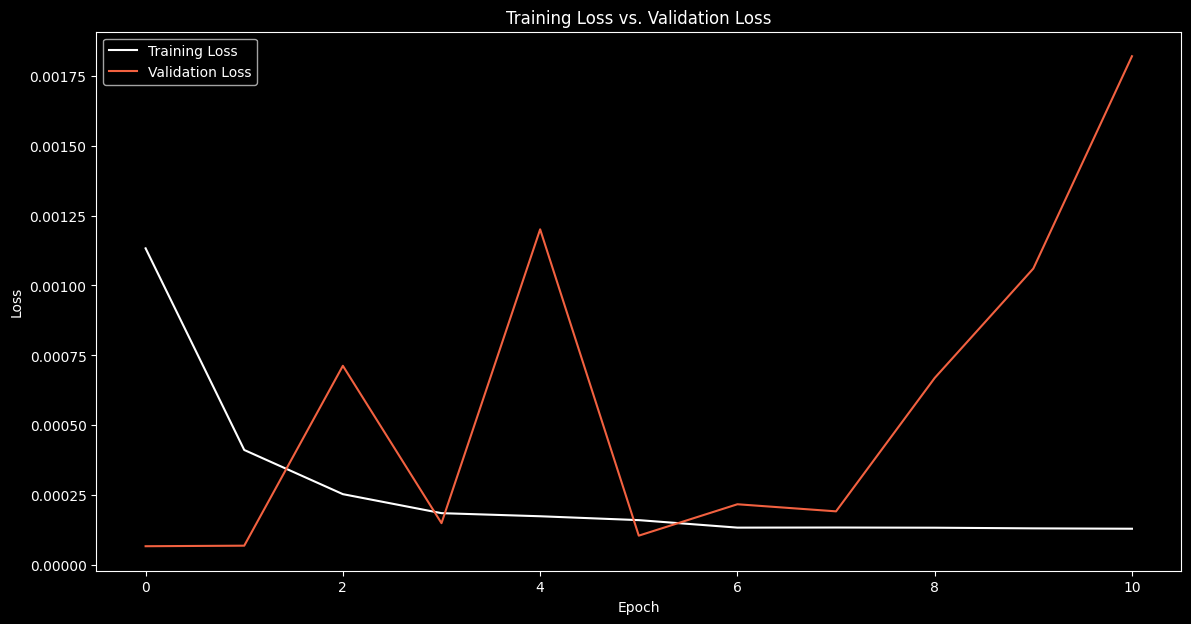

1584/1584 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 1.2950e-04 - val_loss: 0.0018 - learning_rate: 5.0000e-04
Trained and saved a new GRU regression model.
792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
GRU Regression Model MSE: 6.782646191926048e-05


In [120]:
def build_bidirectional_gru_attention_model_regression(input_shape):
    inputs = Input(shape=input_shape)

    # First GRU Layer
    gru = GRU(512, return_sequences=True)(inputs)
    attention = Attention()([gru, gru])
    x = Dropout(0.3)(attention)

    # Second GRU Layer
    x = GRU(256, return_sequences=True)(x)
    x = Dropout(0.3)(x)

    # Third GRU Layer
    x = GRU(128, return_sequences=False)(x)
    x = Dropout(0.3)(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    return model

# GRU regression model
gru_reg_filename = f'gru_reg_model_{index_symbol}_{interval_minutes}.keras'
sanitized_gru_reg_filename = sanitize_filename(gru_reg_filename)
gru_reg_model_path = f'models/{sanitized_gru_reg_filename}'

if os.path.exists(gru_reg_model_path) and is_file_from_past_week(gru_reg_model_path):
    gru_reg_model = load_model(gru_reg_model_path)
    print("Loaded existing GRU regression model.")
else:
    input_shape = (X_train_reg.shape[1], X_train_reg.shape[2])
    gru_reg_model = build_bidirectional_gru_attention_model_regression(input_shape)
    gru_reg_model.compile(optimizer='adam', loss='mean_squared_error')

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
    checkpoint = ModelCheckpoint(gru_reg_model_path, monitor='val_loss', save_best_only=True, save_weights_only=False, mode='min')

    gru_reg_model.fit(
        X_train_reg, y_train_reg,
        validation_data=(X_test_reg, y_test_reg),
        epochs=100,
        batch_size=64,
        callbacks=[early_stopping, reduce_lr, checkpoint, PlotLosses()],
        verbose=1
    )
    print("Trained and saved a new GRU regression model.")

# Make predictions for regression
y_pred_gru_reg = gru_reg_model.predict(X_test_reg)
y_pred_gru_reg = np.squeeze(y_pred_gru_reg)

# Evaluate the regression model
mse_gru_reg = mean_squared_error(y_test_reg, y_pred_gru_reg)
print(f'GRU Regression Model MSE: {mse_gru_reg}')

In [121]:
# Inverse of MSE (higher is better)
inv_mse_lr_reg = 1 / mse_lr_reg
inv_mse_lstm_reg = 1 / mse_lstm_reg
inv_mse_gru_reg = 1 / mse_gru_reg

# Step 2: Normalize the weights
total_inv_mse_reg = inv_mse_lr_reg + inv_mse_lstm_reg + inv_mse_gru_reg

weight_lr_reg = inv_mse_lr_reg / total_inv_mse_reg
weight_lstm_reg = inv_mse_lstm_reg / total_inv_mse_reg
weight_gru_reg = inv_mse_gru_reg / total_inv_mse_reg

print(f'Weights: LR={weight_lr_reg:.2f}, LSTM={weight_lstm_reg:.2f}, GRU={weight_gru_reg:.2f}')

Weights: LR=0.90, LSTM=0.08, GRU=0.02


In [122]:
# Step 3: Use these weights to combine the predictions
y_pred_ensemble_reg = (weight_lr_reg * y_pred_lr_reg) + (weight_lstm_reg * y_pred_lstm_reg) + (weight_gru_reg * y_pred_gru_reg)

# Calculate the MSE of the ensemble model
mse_ensemble_reg = mean_squared_error(y_test_reg, y_pred_ensemble_reg)
print(f'Ensemble Model MSE: {mse_ensemble_reg}')

Ensemble Model MSE: 1.7596824887080703e-06


In [123]:
# Inverse transform predictions for Linear Regression Model
y_pred_lr_original = regression_scalers['close'].inverse_transform(y_pred_lr_reg.reshape(-1, 1)).flatten()
r2_lr = r2_score(regression_scalers['close'].inverse_transform(y_test_reg.reshape(-1, 1)), y_pred_lr_original)

# Inverse transform predictions for LSTM Model
y_pred_lstm_original = regression_scalers['close'].inverse_transform(y_pred_lstm_reg.reshape(-1, 1)).flatten()
r2_lstm = r2_score(regression_scalers['close'].inverse_transform(y_test_reg.reshape(-1, 1)), y_pred_lstm_original)

# Inverse transform predictions for gru Model
y_pred_gru_original = regression_scalers['close'].inverse_transform(y_pred_gru_reg.reshape(-1, 1)).flatten()
r2_gru = r2_score(regression_scalers['close'].inverse_transform(y_test_reg.reshape(-1, 1)), y_pred_gru_original)

# Inverse transform predictions for Ensemble Model
y_pred_ensemble_original = regression_scalers['close'].inverse_transform(y_pred_ensemble_reg.reshape(-1, 1)).flatten()
r2_ensemble = r2_score(regression_scalers['close'].inverse_transform(y_test_reg.reshape(-1, 1)), y_pred_ensemble_original)

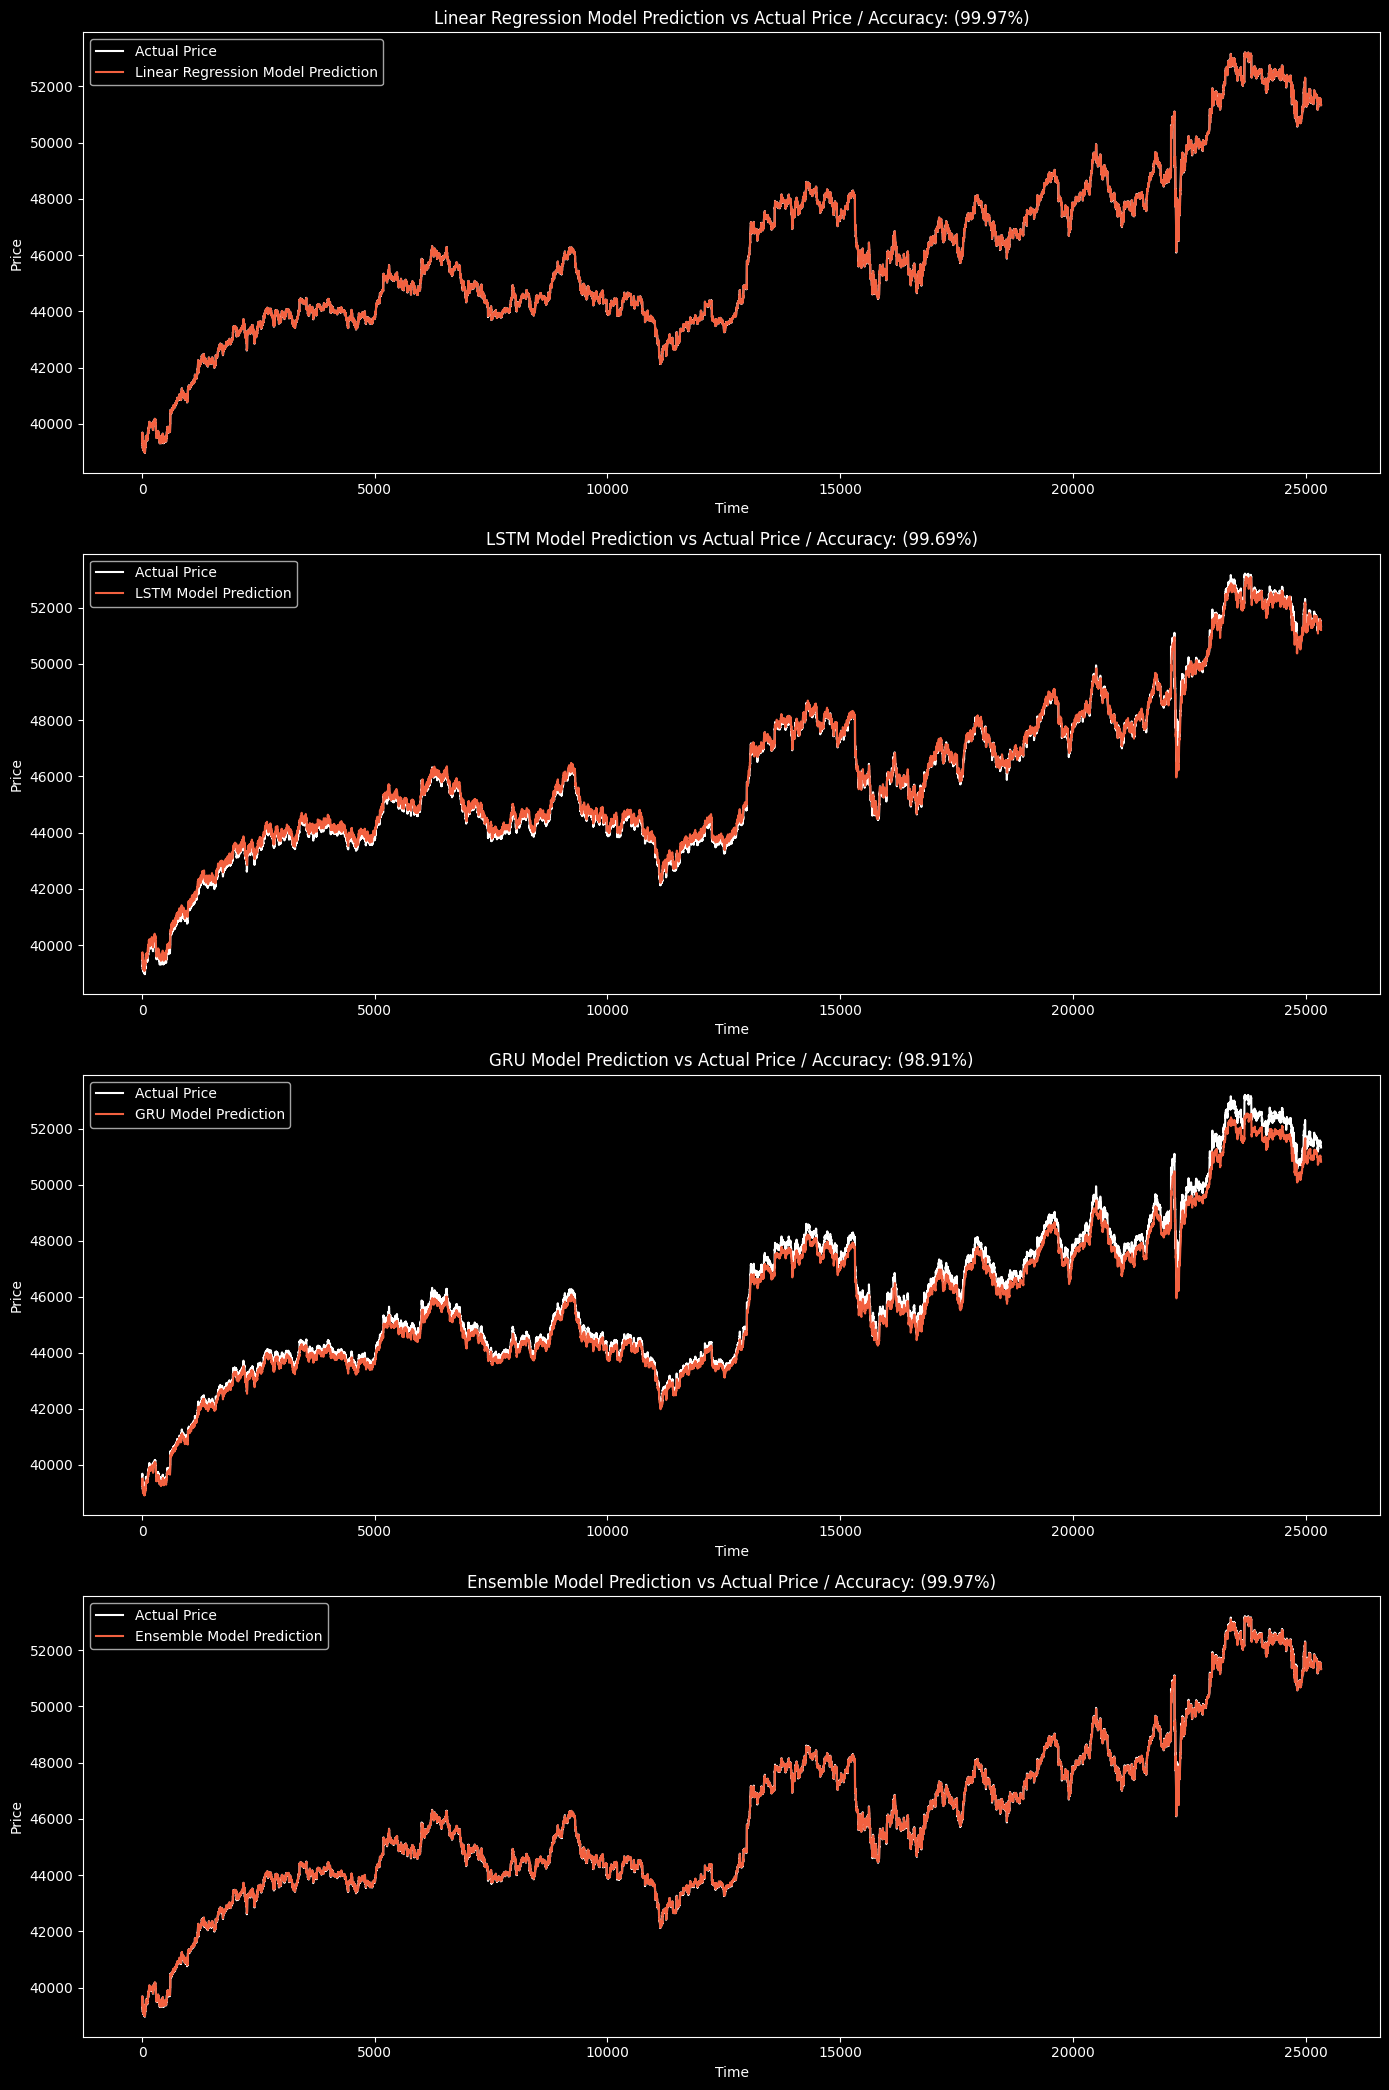

In [124]:
# Apply dark background style
plt.style.use('dark_background')

# Plot the predicted graphs for each model separately
plt.figure(figsize=(14, 21))

# Colors for the plots
actual_color = 'white'
predicted_color = (0.95, 0.38, 0.25, 1)

# Plot for GRU Model
plt.subplot(4, 1, 1)
plt.plot(regression_scalers['close'].inverse_transform(y_test_reg.reshape(-1, 1)), label='Actual Price', color=actual_color)
plt.plot(y_pred_lr_original, label='Linear Regression Model Prediction', color=predicted_color)
plt.title(f'Linear Regression Model Prediction vs Actual Price / Accuracy: ({r2_lr * 100:.2f}%)', color='white')
plt.xlabel('Time', color='white')
plt.ylabel('Price', color='white')
plt.legend()
plt.grid(False)
plt.tick_params(colors='white')

# Plot for LSTM Model
plt.subplot(4, 1, 2)
plt.plot(regression_scalers['close'].inverse_transform(y_test_reg.reshape(-1, 1)), label='Actual Price', color=actual_color)
plt.plot(y_pred_lstm_original, label='LSTM Model Prediction', color=predicted_color)
plt.title(f'LSTM Model Prediction vs Actual Price / Accuracy: ({r2_lstm * 100:.2f}%)', color='white')
plt.xlabel('Time', color='white')
plt.ylabel('Price', color='white')
plt.legend()
plt.grid(False)
plt.tick_params(colors='white')

# Plot for GRU Model
plt.subplot(4, 1, 3)
plt.plot(regression_scalers['close'].inverse_transform(y_test_reg.reshape(-1, 1)), label='Actual Price', color=actual_color)
plt.plot(y_pred_gru_original, label='GRU Model Prediction', color=predicted_color)
plt.title(f'GRU Model Prediction vs Actual Price / Accuracy: ({r2_gru * 100:.2f}%)', color='white')
plt.xlabel('Time', color='white')
plt.ylabel('Price', color='white')
plt.legend()
plt.grid(False)
plt.tick_params(colors='white')

# Plot for Ensemble Model
plt.subplot(4, 1, 4)
plt.plot(regression_scalers['close'].inverse_transform(y_test_reg.reshape(-1, 1)), label='Actual Price', color=actual_color)
plt.plot(y_pred_ensemble_original, label='Ensemble Model Prediction', color=predicted_color)
plt.title(f'Ensemble Model Prediction vs Actual Price / Accuracy: ({r2_ensemble * 100:.2f}%)', color='white')
plt.xlabel('Time', color='white')
plt.ylabel('Price', color='white')
plt.legend()
plt.grid(False)
plt.tick_params(colors='white')

plt.tight_layout()
plt.show()

In [125]:
def format_capital(capital):
    # Check if the value is negative
    negative = capital < 0
    # Use the absolute value for formatting
    capital = abs(capital)

    if capital >= 1_00_00_00_00_00_00_000:  # 1 Shankh
        formatted_value = f'{capital / 1_00_00_00_00_00_00_000:.2f} Shankh'
    elif capital >= 1_00_00_00_00_00_00_000:  # 1 Padma
        formatted_value = f'{capital / 1_00_00_00_00_00_00_000:.2f} Padma'
    elif capital >= 1_00_00_00_00_00_000:  # 1 Nil
        formatted_value = f'{capital / 1_00_00_00_00_00_000:.2f} Nil'
    elif capital >= 1_00_00_00_00_000:  # 1 Kharab
        formatted_value = f'{capital / 1_00_00_00_00_000:.2f} Kharab'
    elif capital >= 1_00_00_00_000:  # 1 Arab
        formatted_value = f'{capital / 1_00_00_00_000:.2f} Arab'
    elif capital >= 1_00_00_000:  # 1 Crore
        formatted_value = f'{capital / 1_00_00_000:.2f} Cr'
    elif capital >= 1_00_000:  # 1 Lakh
        formatted_value = f'{capital / 1_00_000:.2f} L'
    elif capital >= 1_000:  # 1 Thousand
        formatted_value = f'{capital / 1_000:.2f} K'
    else:
        formatted_value = f'{capital:.2f}'

    # Prepend the negative sign if needed
    return f'-{formatted_value}' if negative else formatted_value

In [126]:
# Function to format trade time
def format_trade_time(seconds):
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)

    if hours > 0:
        return f"{int(hours)} Hour{'s' if hours > 1 else ''} {int(minutes)} Min{'s' if minutes > 1 else ''}"
    elif minutes > 0:
        return f"{int(minutes)} Min{'s' if minutes > 1 else ''}"
    else:
        return f"{int(seconds)} Sec{'S' if seconds > 1 else ''}"

In [154]:
backtest_candle_data = fetch_candle_data(20)

raw_backtest_df = pd.DataFrame(backtest_candle_data['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])

print(len(raw_backtest_df))

raw_backtest_df = raw_backtest_df.drop_duplicates(subset='datetime', keep='first')
raw_backtest_df

print(len(raw_backtest_df))

1062
1062


In [155]:
initial_capital = 10000
backtest_results = []

crop_fetched_candle_data = 599

def backtest_logic():
    global backtest_results

    backtest_capital = initial_capital
    backtest_quantity = quantity
    temp_capital = initial_capital

    total_backtest_profits = 0
    total_backtest_losses = 0
    total_backtest_brokerage = 0

    backtest_trade_active = False
    backtest_entry_price = 0
    backtest_target_price = 0
    backtest_stop_loss_price = 0

    entry_type = None
    backtest_entry_datetime = None
    entry_ensemble_prediction = None
    entry_rf_prediction = None

    for i in range(crop_fetched_candle_data, len(raw_backtest_df)):
        if backtest_capital > 2 * temp_capital:
            backtest_quantity *= 2
            temp_capital *= 2

        backtest_df = raw_backtest_df[i-crop_fetched_candle_data:i+1].copy()

        backtest_df = process_df_with_features(backtest_df)
        backtest_df = label_signals(backtest_df)

        backtest_df = backtest_df[[col for col in backtest_df.columns if col not in ['Entry Price', 'Exit Price']]]

        print(len(backtest_df))

        backtest_df = backtest_df.iloc[:-1]

        # Regression Prediction
        scaled_backtest_reg_df = backtest_df[-sequence_length:].copy()
        for column in scaled_backtest_reg_df.columns:
            scaled_backtest_reg_df[column] = regression_scalers[column].transform(scaled_backtest_reg_df[column].values.reshape(-1, 1))

        current_sequence_reg = scaled_backtest_reg_df.values
        current_sequence_reg = current_sequence_reg.reshape(1, sequence_length, -1)

        y_pred_lr_reg_backtest = None
        y_pred_lstm_reg_backtest = None
        y_pred_gru_reg_backtest = None
        y_pred_ensemble_reg_backtest = None
        y_pred_ensemble_reg_backtest_original = None

        current_time = backtest_df.index[-1].time()

        # Actual Closing Price
        actual_closing_original = backtest_df['close'].iloc[-1]

        if not backtest_trade_active and current_time >= dt_time(9, (15 + interval_minutes)) and current_time <= dt_time(15, 0):
            y_pred_lr_reg_backtest = lr_reg_model.predict(current_sequence_reg.reshape(current_sequence_reg.shape[0], -1))

            y_pred_lstm_reg_backtest = lstm_reg_model.predict(current_sequence_reg)
            y_pred_lstm_reg_backtest = np.squeeze(y_pred_lstm_reg_backtest)


            y_pred_gru_reg_backtest = gru_reg_model.predict(current_sequence_reg)
            y_pred_gru_reg_backtest = np.squeeze(y_pred_gru_reg_backtest)

            y_pred_ensemble_reg_backtest = (weight_lr_reg * y_pred_lr_reg_backtest) + (weight_lstm_reg * y_pred_lstm_reg_backtest) + (weight_gru_reg * y_pred_gru_reg_backtest)

            y_pred_ensemble_reg_backtest_original = regression_scalers['close'].inverse_transform(y_pred_ensemble_reg_backtest.reshape(-1, 1)).flatten()
            y_pred_ensemble_reg_backtest_original = round(y_pred_ensemble_reg_backtest_original[0], 2)

            rf_backtest_data = backtest_df.iloc[-1:][[col for col in backtest_df.columns if col != 'Signal']]
            y_pred_rf_backtest = rf_model.predict(rf_backtest_data)
            y_pred_rf_backtest = y_pred_rf_backtest[0]

            print(f'Actual Closing Price: {actual_closing_original}')
            print(f'Predicted Price: {y_pred_ensemble_reg_backtest_original}')
            print(f"RF Prediction: {y_pred_rf_backtest}")

        print(backtest_df.index[-1])

        if current_time >= dt_time(9, (15 + interval_minutes)) and current_time <= dt_time(15, 0):
            if not backtest_trade_active and entry_type == None:
                if y_pred_rf_backtest == 2 and y_pred_ensemble_reg_backtest >= actual_closing_original:
                    backtest_entry_price = actual_closing_original

                    backtest_target_price = int(backtest_entry_price + backtest_df['Target'].iloc[-1])
                    backtest_stop_loss_price = int(backtest_entry_price - backtest_df['Stop Loss'].iloc[-1])

                    backtest_trade_active = True
                    entry_type = "CE"
                    backtest_entry_datetime = backtest_df.index[-1]
                    entry_ensemble_prediction = y_pred_ensemble_reg_backtest_original
                    entry_rf_prediction = y_pred_rf_backtest

                    print(f"CE Signal at {backtest_df.index[-1]}")
                    print(f"Entry Price: {backtest_entry_price}")
                    print(f"Predicted Price: {y_pred_ensemble_reg_backtest_original}")
                    print(f"Random Forest: {y_pred_rf_backtest}")

                elif y_pred_rf_backtest == 1 and y_pred_ensemble_reg_backtest <= actual_closing_original:
                    backtest_entry_price = actual_closing_original

                    backtest_target_price = int(backtest_entry_price - backtest_df['Target'].iloc[-1])
                    backtest_stop_loss_price = int(backtest_entry_price + backtest_df['Stop Loss'].iloc[-1])

                    backtest_trade_active = True
                    entry_type = "PE"
                    backtest_entry_datetime = backtest_df.index[-1]
                    entry_ensemble_prediction = y_pred_ensemble_reg_backtest_original
                    entry_rf_prediction = y_pred_rf_backtest

                    print(f"PE Signal at {backtest_df.index[-1]}")
                    print(f"Entry Price: {backtest_entry_price}")
                    print(f"Predicted Price: {y_pred_ensemble_reg_backtest_original}")
                    print(f"Random Forest: {y_pred_rf_backtest}")

            else:
                if entry_type == "CE":
                    if actual_closing_original >= backtest_target_price:
                        points = int((backtest_target_price - backtest_entry_price))
                        profits = int(points * backtest_quantity)
                        backtest_capital += profits
                        total_backtest_profits += 1
                        total_backtest_brokerage += brokerage

                        win_percentage = round(total_backtest_profits / (total_backtest_profits + total_backtest_losses) * 100, 2)
                        loss_percentage = round(total_backtest_losses / (total_backtest_profits + total_backtest_losses) * 100, 2)

                        print(f"CE Target hit at {backtest_df.index[-1]}")
                        print(f"Profit: {format_capital(profits)}")
                        print(f'Profit/Loss %: {win_percentage}% / {loss_percentage}%')
                        print(f"Capital: {format_capital(backtest_capital)}")

                        backtest_results.append({
                            'Entry Time': backtest_entry_datetime,
                            'Exit Time': backtest_df.index[-1],
                            'Entry Type': entry_type,
                            'Entry Price': backtest_entry_price,
                            'Exit Price': actual_closing_original,
                            'Quantity': backtest_quantity,
                            'Points': points,
                            'Profit': format_capital(profits),
                            'Accuracy': f"{win_percentage}%",
                            'Capital': format_capital(backtest_capital),
                            'Brokerage': format_capital(total_backtest_brokerage),
                            'Ensemble Prediction': entry_ensemble_prediction,
                            'RF Prediction': entry_rf_prediction
                        })

                        backtest_trade_active = False
                        entry_type = None

                    elif actual_closing_original <= backtest_stop_loss_price:
                        points = int((backtest_stop_loss_price - backtest_entry_price))
                        profits = int(points * backtest_quantity)
                        backtest_capital += profits
                        total_backtest_losses += 1
                        total_backtest_brokerage += brokerage

                        win_percentage = round(total_backtest_profits / (total_backtest_profits + total_backtest_losses) * 100, 2)
                        loss_percentage = round(total_backtest_losses / (total_backtest_profits + total_backtest_losses) * 100, 2)

                        print(f"CE SL hit at {backtest_df.index[-1]}")
                        print(f"Loss: {format_capital(profits)}")
                        print(f'Profit/Loss %: {win_percentage}% / {loss_percentage}%')
                        print(f"Capital: {format_capital(backtest_capital)}")

                        backtest_results.append({
                            'Entry Time': backtest_entry_datetime,
                            'Exit Time': backtest_df.index[-1],
                            'Entry Type': entry_type,
                            'Entry Price': backtest_entry_price,
                            'Exit Price': actual_closing_original,
                            'Quantity': backtest_quantity,
                            'Points': points,
                            'Profit': format_capital(profits),
                            'Accuracy': f"{win_percentage}%",
                            'Capital': format_capital(backtest_capital),
                            'Brokerage': format_capital(total_backtest_brokerage),
                            'Ensemble Prediction': entry_ensemble_prediction,
                            'RF Prediction': entry_rf_prediction
                        })

                        backtest_trade_active = False
                        entry_type = None

                elif entry_type == "PE":
                    if actual_closing_original <= backtest_target_price:
                        points = int((backtest_entry_price - backtest_target_price))
                        profits = int(points * backtest_quantity)
                        backtest_capital += profits
                        total_backtest_profits += 1
                        total_backtest_brokerage += brokerage

                        win_percentage = round(total_backtest_profits / (total_backtest_profits + total_backtest_losses) * 100, 2)
                        loss_percentage = round(total_backtest_losses / (total_backtest_profits + total_backtest_losses) * 100, 2)

                        print(f"PE Target hit at {backtest_df.index[-1]}")
                        print(f"Profit: {format_capital(profits)}")
                        print(f'Profit/Loss %: {win_percentage}% / {loss_percentage}%')
                        print(f"Capital: {format_capital(backtest_capital)}")

                        backtest_results.append({
                            'Entry Time': backtest_entry_datetime,
                            'Exit Time': backtest_df.index[-1],
                            'Entry Type': entry_type,
                            'Entry Price': backtest_entry_price,
                            'Exit Price': actual_closing_original,
                            'Quantity': backtest_quantity,
                            'Points': points,
                            'Profit': format_capital(profits),
                            'Accuracy': f"{win_percentage}%",
                            'Capital': format_capital(backtest_capital),
                            'Brokerage': format_capital(total_backtest_brokerage),
                            'Ensemble Prediction': entry_ensemble_prediction,
                            'RF Prediction': entry_rf_prediction
                        })

                        backtest_trade_active = False
                        entry_type = None

                    elif actual_closing_original >= backtest_stop_loss_price:
                        points = int((backtest_entry_price - backtest_stop_loss_price))
                        profits = int(points * backtest_quantity)
                        backtest_capital += profits
                        total_backtest_losses += 1
                        total_backtest_brokerage += brokerage

                        win_percentage = round(total_backtest_profits / (total_backtest_profits + total_backtest_losses) * 100, 2)
                        loss_percentage = round(total_backtest_losses / (total_backtest_profits + total_backtest_losses) * 100, 2)

                        print(f"PE SL hit at {backtest_df.index[-1]}")
                        print(f"Loss: {format_capital(profits)}")
                        print(f'Profit/Loss %: {win_percentage}% / {loss_percentage}%')
                        print(f"Capital: {format_capital(backtest_capital)}")

                        backtest_results.append({
                            'Entry Time': backtest_entry_datetime,
                            'Exit Time': backtest_df.index[-1],
                            'Entry Type': entry_type,
                            'Entry Price': backtest_entry_price,
                            'Exit Price': actual_closing_original,
                            'Quantity': backtest_quantity,
                            'Points': points,
                            'Profit': format_capital(profits),
                            'Accuracy': f"{win_percentage}%",
                            'Capital': format_capital(backtest_capital),
                            'Brokerage': format_capital(total_backtest_brokerage),
                            'Ensemble Prediction': entry_ensemble_prediction,
                            'RF Prediction': entry_rf_prediction
                        })

                        backtest_trade_active = False
                        entry_type = None

        else:
            backtest_trade_active = False
            entry_type = None

        clear_output(wait=True)

backtest_logic()

586
2024-11-08 15:20:00


In [156]:
backtest_results_df = pd.DataFrame(backtest_results)

backtest_results_df.tail(15)

,Entry Time,Exit Time,Entry Type,Entry Price,Exit Price,Quantity,Points,Profit,Accuracy,Capital,Brokerage,Ensemble Prediction,RF Prediction
14,2024-11-05 13:50:00,2024-11-05 14:00:00,PE,51853.30,52093.40,15,-133,-2.00 K,40.0%,10.62 K,1.50 K,51779.63,1
15,2024-11-05 14:05:00,2024-11-05 15:00:00,PE,52104.90,52257.35,15,-131,-1.97 K,37.5%,8.65 K,1.60 K,52032.81,1
16,2024-11-07 09:20:00,2024-11-07 09:55:00,PE,52124.20,51951.80,15,124,1.86 K,41.18%,10.51 K,1.70 K,52120.78,1
17,2024-11-07 10:00:00,2024-11-07 10:50:00,PE,51803.30,51986.05,15,-81,-1.22 K,38.89%,9.29 K,1.80 K,51809.31,1
18,2024-11-07 10:55:00,2024-11-07 11:15:00,PE,52044.95,51825.70,15,157,2.35 K,42.11%,11.65 K,1.90 K,52002.68,1
19,2024-11-07 11:20:00,2024-11-07 12:35:00,PE,51864.35,51955.95,15,-77,-1.16 K,40.0%,10.49 K,2.00 K,51835.20,1
20,2024-11-07 12:40:00,2024-11-07 13:10:00,PE,51975.70,52061.05,15,-60,-900.00,38.1%,9.60 K,2.10 K,51923.98,1
21,2024-11-07 13:15:00,2024-11-07 13:40:00,PE,51998.55,51857.70,15,113,1.70 K,40.91%,11.29 K,2.20 K,51957.47,1
22,2024-11-07 13:45:00,2024-11-07 14:10:00,PE,51891.00,51948.45,15,-53,-795.00,39.13%,10.49 K,2.30 K,51854.55,1
23,2024-11-08 09:20:00,2024-11-08 09:25:00,PE,51644.40,51830.45,15,-65,-975.00,37.5%,9.52 K,2.40 K,51663.54,1


In [157]:
def parse_capital(formatted_value):
    suffixes = {
        'Shankh': 1_00_00_00_00_00_00_000,
        'Padma': 1_00_00_00_00_00_00_000,
        'Nil': 1_00_00_00_00_00_000,
        'Kharab': 1_00_00_00_00_000,
        'Arab': 1_00_00_00_000,
        'Cr': 1_00_00_000,
        'L': 1_00_000,
        'K': 1_000
    }

    for suffix, multiplier in suffixes.items():
        if formatted_value.endswith(suffix):
            return float(formatted_value.replace(suffix, '').strip()) * multiplier

    return float(formatted_value)

# Convert the columns back to float
backtest_results_df['Inv_Capital'] = backtest_results_df['Capital'].apply(parse_capital)

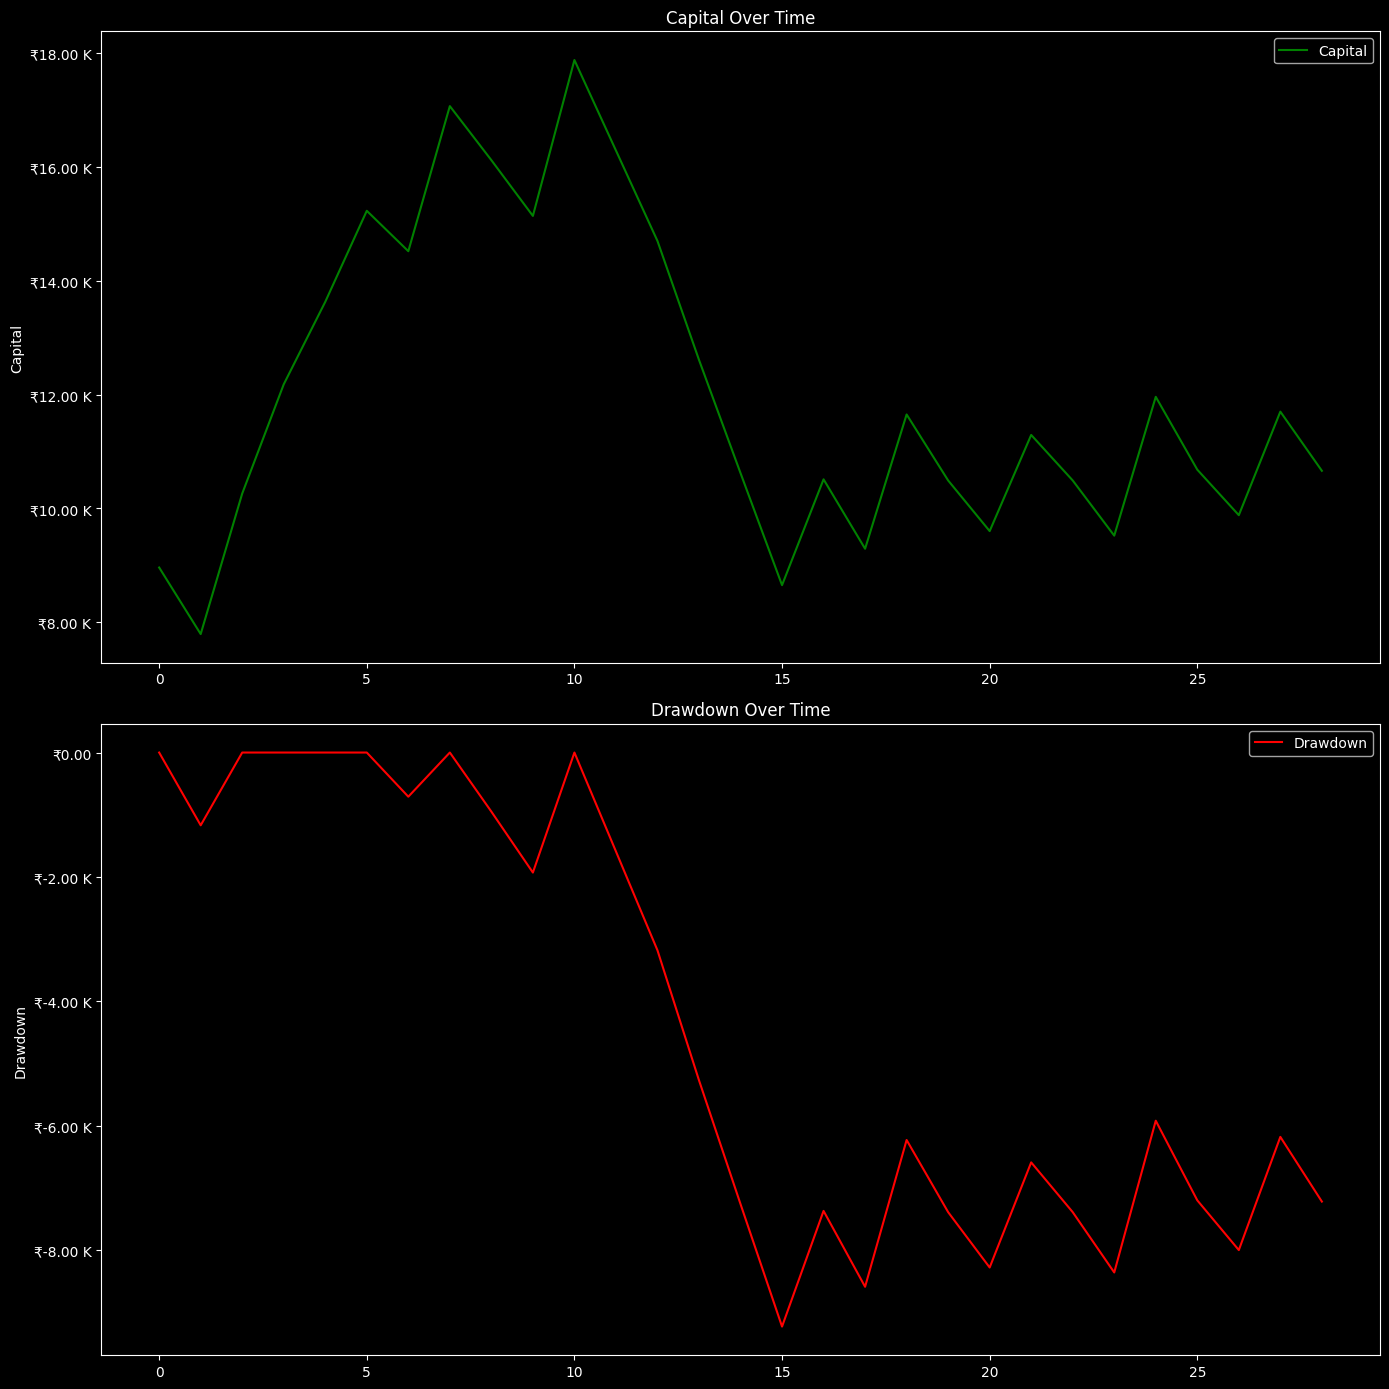

In [158]:
def currency(x, pos):
    return f'₹{format_capital(x)}'

# Calculate drawdown
backtest_results_df['Drawdown'] = backtest_results_df['Inv_Capital'].cummax() - backtest_results_df['Inv_Capital']
backtest_results_df['Drawdown Percent'] = (backtest_results_df['Drawdown'] / backtest_results_df['Inv_Capital'].cummax()) * 100

backtest_results_df['Temp_Profit'] = backtest_results_df['Inv_Capital'] - backtest_results_df['Drawdown']

# Plot drawdown
plt.style.use('dark_background')
plt.figure(figsize=(14, 14))

formatter = FuncFormatter(currency)

plt.subplot(2, 1, 1)
plt.plot(backtest_results_df.index, backtest_results_df['Inv_Capital'], color='green', label='Capital')
plt.ylabel('Capital', color='white')
plt.title('Capital Over Time', color='white')
plt.legend()
plt.grid(False)
plt.tick_params(colors='white')
plt.gca().yaxis.set_major_formatter(formatter)

plt.subplot(2, 1, 2)
plt.plot(backtest_results_df.index, -backtest_results_df['Drawdown'], label='Drawdown', color='red')
plt.ylabel('Drawdown', color='white')
plt.title('Drawdown Over Time', color='white')
plt.legend()
plt.grid(False)
plt.tick_params(colors='white')
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [159]:
def get_sleep_time(interval_minutes, market_start_hour=9, market_start_minute=15):
    now = datetime.now()
    market_start_time = now.replace(hour=market_start_hour, minute=market_start_minute, second=0, microsecond=0)

    if now < market_start_time:
        # If current time is before the market starts, set next_run_time to market start time
        next_run_time = market_start_time
    else:
        # Calculate the minutes since the market start time
        minutes_since_market_start = (now - market_start_time).total_seconds() // 60
        # Calculate the number of minutes to the next interval boundary
        minutes_to_next_interval = interval_minutes - (minutes_since_market_start % interval_minutes)
        # Calculate the next run time by adding these minutes to the current time
        next_run_time = (now + timedelta(minutes=minutes_to_next_interval)).replace(second=0, microsecond=0)

    # Calculate the sleep time in seconds
    sleep_time = (next_run_time - now).total_seconds()
    return sleep_time

In [160]:
def fetch_option_chain():
    while True:
        try:
            data = {
                "symbol": index_symbol,
                "strikecount": 2,
                "timestamp": ""
            }
            response = fyers.optionchain(data=data)

            if response is not None:
                return response
        except Exception as e:
            print(f"Error fetching Option Chain: {e}")
            time.sleep(active_order_sleep)

index_oc= fetch_option_chain()

pd.DataFrame(index_oc['data']['optionsChain'])

,ask,bid,description,ex_symbol,exchange,fp,fpch,fpchp,fyToken,ltp,ltpch,ltpchp,option_type,strike_price,symbol,oi,oich,oichp,prev_oi,volume
0,0.00,0.00,NIFTYBANK-INDEX,BANKNIFTY,NSE,51759.0,-440.9,-0.84,101000000026009,51561.20,-355.30,-0.68,,-1,NSE:NIFTYBANK-INDEX,NaN,NaN,NaN,NaN,NaN
1,266.45,264.10,NaN,NaN,NaN,NaN,NaN,NaN,101124111347439,264.55,60.50,29.65,PE,51400,NSE:BANKNIFTY24N1351400PE,310065.0,-21465.0,-6.47,331530.0,17781240.0
2,424.05,416.70,NaN,NaN,NaN,NaN,NaN,NaN,101124111347438,421.60,-384.85,-47.72,CE,51400,NSE:BANKNIFTY24N1351400CE,140520.0,103485.0,279.42,37035.0,4902540.0
3,310.00,305.95,NaN,NaN,NaN,NaN,NaN,NaN,101124111347443,310.00,78.05,33.65,PE,51500,NSE:BANKNIFTY24N1351500PE,1101825.0,265605.0,31.76,836220.0,42060255.0
4,365.00,363.55,NaN,NaN,NaN,NaN,NaN,NaN,101124111347440,363.55,-371.50,-50.54,CE,51500,NSE:BANKNIFTY24N1351500CE,640710.0,420600.0,191.09,220110.0,20469660.0
5,361.50,356.45,NaN,NaN,NaN,NaN,NaN,NaN,101124111347446,356.45,94.60,36.13,PE,51600,NSE:BANKNIFTY24N1351600PE,630660.0,326220.0,107.15,304440.0,40947315.0
6,314.80,312.00,NaN,NaN,NaN,NaN,NaN,NaN,101124111347444,312.00,-355.00,-53.22,CE,51600,NSE:BANKNIFTY24N1351600CE,493845.0,427590.0,645.37,66255.0,26911800.0
7,270.00,267.65,NaN,NaN,NaN,NaN,NaN,NaN,101124111347447,270.00,-332.70,-55.20,CE,51700,NSE:BANKNIFTY24N1351700CE,554085.0,400755.0,261.37,153330.0,30018045.0
8,414.90,411.00,NaN,NaN,NaN,NaN,NaN,NaN,101124111347448,414.90,118.95,40.19,PE,51700,NSE:BANKNIFTY24N1351700PE,472140.0,152430.0,47.68,319710.0,39931515.0
9,476.70,471.15,NaN,NaN,NaN,NaN,NaN,NaN,101124111347455,475.75,142.25,42.65,PE,51800,NSE:BANKNIFTY24N1351800PE,393450.0,-51075.0,-11.49,444525.0,35157435.0


In [161]:
def assign_ce_pe_option_symbols():
    symbol_oc = fetch_option_chain()

    if symbol_oc != None:
        # Convert the response data into a DataFrame
        oc_df = pd.DataFrame(symbol_oc['data']['optionsChain'])

        # Find the first 'CE' symbol from the top
        first_ce_symbol = None
        for index, row in oc_df.iterrows():
            if row['option_type'] == 'CE':
                first_ce_symbol = row['symbol']
                first_ce_strike = row['strike_price']
                break

        # Find the first 'PE' symbol from the bottom
        first_pe_symbol = None
        for index, row in oc_df[::-1].iterrows():  # Iterate in reverse
            if row['option_type'] == 'PE':
                first_pe_symbol = row['symbol']
                first_pe_strike = row['strike_price']
                break

        return first_ce_symbol, first_pe_symbol, first_ce_strike, first_pe_strike

In [162]:
def onmessage_ce(ce_message):
    global ce_ltp, index_ltp, unsubscribe_done
    try:
        if ce_message['symbol'] == ce_symbol:
            if "ltp" in ce_message:
                ce_ltp = ce_message["ltp"]
                ce_ltp = float(ce_ltp)

        elif ce_message['symbol'] == index_symbol:
            if "ltp" in ce_message:
                index_ltp = ce_message["ltp"]
                index_ltp = float(index_ltp)

        if sl_hit_condition and not unsubscribe_done:
            data_type = "SymbolUpdate"
            symbols_to_unsubscribe = [ce_symbol, index_symbol]
            fyers_socket.unsubscribe(symbols=symbols_to_unsubscribe, data_type=data_type)

            unsubscribe_done = True  # Set the flag to True after unsubscribing

            print(f"Unsubscribed {ce_symbol} & {index_symbol}")

    except Exception as e:
        print(f"Error (onMessageCE): {e}")


def onerror_ce(message):
    print("CE Error:", message)


def onclose_ce(message):
    print("CE Connection closed:", message)


def onopen_ce():

    # Specify the data type and symbols you want to subscribe to
    data_type = "SymbolUpdate"

    # Subscribe to the specified symbols and data type
    symbols = [ce_symbol, index_symbol]
    fyers_socket.subscribe(symbols=symbols, data_type=data_type)

    # Keep the socket running to receive real-time data
    fyers_socket.keep_running()

# Function to fetch and return the Call Option's Last Traded Price (LTP), strike, and symbol.
def ce_buy_sell_ltp():
    global buy_sell_checked, ce_symbol, ce_strike
    try:
        if not buy_sell_checked:
            buy_sell_checked = True

            print("Fetching CE Strike Price LTP")

            ce_symbol, pe_symbol, ce_strike, pe_strike = assign_ce_pe_option_symbols()

            if ce_symbol is not None and ce_strike is not None:
                # Create a FyersDataSocket instance with the provided parameters
                ce_socket_fyers = data_ws.FyersDataSocket(
                    access_token=ws_token,       # Access token in the format "appid:accesstoken"
                    log_path="",                     # Path to save logs. Leave empty to auto-create logs in the current directory.
                    litemode=True,                  # Lite mode disabled. Set to True if you want a lite response.
                    write_to_file=False,              # Save response in a log file instead of printing it.
                    reconnect=True,                  # Enable auto-reconnection to WebSocket on disconnection.
                    on_connect=onopen_ce,               # Callback function to subscribe to data upon connection.
                    on_close=onclose_ce,                # Callback function to handle WebSocket connection close events.
                    on_error=onerror_ce,                # Callback function to handle WebSocket errors.
                    on_message=onmessage_ce             # Callback function to handle incoming messages from the WebSocket.
                )

                # Establish a connection to the Fyers WebSocket
                ce_socket_fyers.connect()

    except Exception as e:
        print(f"Error fetching CE Buy/Sell LTP: {e}")

In [163]:
def onmessage_pe(pe_message):
    global pe_ltp, index_ltp, unsubscribe_done
    try:
        if pe_message['symbol'] == pe_symbol:
            if "ltp" in pe_message:
                pe_ltp = pe_message["ltp"]
                pe_ltp = float(pe_ltp)

        elif pe_message['symbol'] == index_symbol:
            if "ltp" in pe_message:
                index_ltp = pe_message["ltp"]
                index_ltp = float(index_ltp)

        if sl_hit_condition and not unsubscribe_done:
            data_type = "SymbolUpdate"
            symbols_to_unsubscribe = [pe_symbol, index_symbol]
            fyers_socket.unsubscribe(symbols=symbols_to_unsubscribe, data_type=data_type)

            unsubscribe_done = True  # Set the flag to True after unsubscribing

            print(f"Unsubscribed {pe_symbol} & {index_symbol}")

    except Exception as e:
        print(f"Error (onMessagePE): {e}")

def onerror_pe(message):
    print("PE Error:", message)


def onclose_pe(message):
    print("PE Connection closed:", message)


def onopen_pe():
    # Specify the data type and symbols you want to subscribe to
    data_type = "SymbolUpdate"

    # Subscribe to the specified symbols and data type
    symbols = [pe_symbol, index_symbol]
    fyers_socket.subscribe(symbols=symbols, data_type=data_type)

    # Keep the socket running to receive real-time data
    fyers_socket.keep_running()

# Function to fetch and return the Call Option's Last Traded Price (LTP), strike, and symbol.
def pe_buy_sell_ltp():
    global buy_sell_checked, pe_symbol, pe_strike
    try:
        if not buy_sell_checked:
            buy_sell_checked = True

            print("Fetching PE Strike Price LTP")

            ce_symbol, pe_symbol, ce_strike, pe_strike = assign_ce_pe_option_symbols()

            if pe_symbol is not None and pe_strike is not None:
                # Create a FyersDataSocket instance with the provided parameters
                pe_socket_fyers = data_ws.FyersDataSocket(
                    access_token=ws_token,       # Access token in the format "appid:accesstoken"
                    log_path="",                     # Path to save logs. Leave empty to auto-create logs in the current directory.
                    litemode=True,                  # Lite mode disabled. Set to True if you want a lite response.
                    write_to_file=False,              # Save response in a log file instead of printing it.
                    reconnect=True,                  # Enable auto-reconnection to WebSocket on disconnection.
                    on_connect=onopen_pe,               # Callback function to subscribe to data upon connection.
                    on_close=onclose_pe,                # Callback function to handle WebSocket connection close events.
                    on_error=onerror_pe,                # Callback function to handle WebSocket errors.
                    on_message=onmessage_pe             # Callback function to handle incoming messages from the WebSocket.
                )

                # Establish a connection to the Fyers WebSocket
                pe_socket_fyers.connect()

    except Exception as e:
        print(f"Error fetching CE Buy/Sell LTP: {e}")

In [164]:
def place_order(symbol):
    try:
        market_order_data = {
            "symbol": symbol,
            "qty": int(quantity),
            "type": 2,  # Market Order
            "side": 1,
            "productType": "INTRADAY",
            "limitPrice": 0,
            "stopPrice": 0,
            "validity": "DAY",
            "disclosedQty": 0,
            "offlineOrder":False
        }

        market_order_entry = fyers.place_order(data=market_order_data)

        if "id" in market_order_entry:
            market_order_id = market_order_entry["id"]
            market_order_message = market_order_entry["message"]
            print(f"{market_order_message}")

    except Exception as e:
        print(f"Error placing orders: {str(e)}")

In [165]:
def trail_order(symbol, stoploss):
    while True:
        try:
            stoploss = int(stoploss)
            pending_order = fyers.orderbook()

            matching_orders = [order for order in pending_order["orderBook"] if order["status"] == 6]

            modified_orders = 0

            for order in matching_orders:
                if order['symbol'] == symbol:
                    pending_order_id = order['id']
                    pending_order_side = order['side']
                    pending_order_side = int(pending_order_side)

                    if pending_order_side != 1:
                        data = {
                            "id": pending_order_id,
                            "type": 4,
                            "limitPrice": stoploss - 1,
                            "stopPrice": stoploss
                        }

                        modify = fyers.modify_order(data=data)
                        trail_message = modify["message"]
                        print(f"{trail_message}")

                        if trail_message == "Successfully modified order":
                            modified_orders += 1

            # Check if all matching orders are successfully modified
            if modified_orders == len(matching_orders):
                break

            time.sleep(active_order_sleep)

        except Exception as e:
            print("Error modifying order:" + str(e))

In [166]:
def exit_active_order(symbol):
    while True:
        try:
            data = {
                "id":f"{symbol}-INTRADAY"
            }

            exit_response = fyers.exit_positions(data=data)

            if ["message"] in exit_response:
                print(exit_response["message"])
                break

            time.sleep(active_order_sleep)

        except Exception as e:
            print(f"Error exiting Order: {e}")

In [167]:
def reset_flags():
    global active_order, buy_sell_checked

    active_order = False
    buy_sell_checked = False

In [168]:
# Function to save profits and losses
def save_overall(overall_win, overall_loss, capital):
    trade_type = {
        "overall_win": overall_win,
        "overall_loss": overall_loss,
        "capital": capital
    }

    with open("trade_data.json", "w") as file:
        json.dump(trade_type, file)


# Function to load wins and losses
def load_overall():
    try:
        with open('trade_data.json') as file:
            return json.load(file)
    except FileNotFoundError:
        return None

In [169]:
def handle_active_ce_order():
    def ce_order_loop():
        global prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, total_profit, total_loss, overall_win, overall_loss, ce_ltp, index_ltp, ce_strike, ce_symbol, sl_hit_condition, total_points, fixed_ltp, fixed_index_ltp, target, trailing_sl

        profit_money = 0
        overall_win = 0
        overall_loss = 0
        capital = 0
        profit_percentage = 0
        loss_percentage = 0

        ce_ltp_array = []
        index_ltp_array = []

        target_hit_once = False

        while True:
            try:
                if ce_ltp != 0 and index_ltp != 0:
                    ce_ltp_array.append(ce_ltp)
                    index_ltp_array.append(index_ltp)

                    trade_data = load_overall()

                    if trade_data:
                        overall_win = trade_data["overall_win"]
                        overall_loss = trade_data["overall_loss"]
                        capital = trade_data["capital"]

                    total_trades = overall_win + overall_loss

                    if overall_win > 0:
                        profit_percentage = (overall_win/total_trades) * 100
                        profit_percentage = round(profit_percentage, 2)

                    if overall_loss > 0:
                        loss_percentage = (overall_loss/total_trades) * 100
                        loss_percentage = round(loss_percentage, 2)


                    if index_ltp <= trailing_index_inside:
                        pygame.mixer.music.play()

                        #exit_active_order(ce_symbol)

                        points = int(ce_ltp) - int(fixed_ltp)

                        total_points = total_points + points

                        if points > 0:
                            total_profit += 1
                            overall_win += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)


                        elif points < 0:
                            total_loss += 1
                            overall_loss += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)

                        profit_money = points*quantity
                        capital = (capital + profit_money) - brokerage
                        save_overall(overall_win, overall_loss, capital)

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        clear_output(wait=True)

                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(ce_ltp_array, label=f"LTP: {ce_ltp}", color='white')
                        plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                        plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                        plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("CE Order LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display profit/loss information as text annotations
                        plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                        plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                        plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                        plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("Index LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        sl_hit_condition = True

                        reset_flags()

                        break

                    elif index_ltp >= target_index_inside:
                        pygame.mixer.music.play()

                        if not target_hit_once:
                            target_hit_once = True
                            target /= 2
                            stop_loss =  trailing_sl / 10

                            target_inside = int(ce_ltp + target)
                            target_index_inside = int(index_ltp + target)

                            trailing_sl_inside = int(ce_ltp - stop_loss)
                            trailing_index_inside = int(index_ltp - stop_loss)

                            trailing_sl /= 2
                            prev_ltp = trailing_index_inside

                        else:
                            target_inside = int(ce_ltp + target)
                            target_index_inside = int(index_ltp + target)

                    else:
                        if (index_ltp - prev_ltp) >= trailing_sl and target_hit_once:
                            pygame.mixer.music.play()

                            prev_ltp = index_ltp

                            trailing_sl_inside = int(ce_ltp - trailing_sl)
                            trailing_index_inside = int(index_ltp - trailing_sl)

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    clear_output(wait=True)

                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(ce_ltp_array, label=f"LTP: {ce_ltp}", color='white')
                    plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                    plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                    plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("CE Order LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display profit/loss information as text annotations
                    plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                    plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                    plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                    plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("Index LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                time.sleep(active_order_sleep)

            except Exception as e:
                print(f"Error: {e}")

    threading.Thread(target=ce_order_loop()).start()

In [170]:
def handle_active_pe_order():
    def pe_order_loop():
        global prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, total_profit, total_loss, overall_win, overall_loss, pe_ltp, index_ltp, pe_strike, pe_symbol, sl_hit_condition, total_points, fixed_ltp, fixed_index_ltp, target, trailing_sl

        profit_money = 0
        overall_win = 0
        overall_loss = 0
        capital = 0
        profit_percentage = 0
        loss_percentage = 0

        pe_ltp_array = []
        index_ltp_array = []

        target_hit_once = False

        while True:
            try:
                if pe_ltp != 0 and index_ltp != 0:
                    pe_ltp_array.append(pe_ltp)
                    index_ltp_array.append(index_ltp)

                    trade_data = load_overall()

                    if trade_data:
                        overall_win = trade_data["overall_win"]
                        overall_loss = trade_data["overall_loss"]
                        capital = trade_data["capital"]

                    total_trades = overall_win + overall_loss

                    if overall_win > 0:
                        profit_percentage = (overall_win/total_trades) * 100
                        profit_percentage = round(profit_percentage, 2)

                    if overall_loss > 0:
                        loss_percentage = (overall_loss/total_trades) * 100
                        loss_percentage = round(loss_percentage, 2)

                    if index_ltp >= trailing_index_inside:
                        pygame.mixer.music.play()

                        #exit_active_order(pe_symbol)

                        points = int(pe_ltp) - int(fixed_ltp)

                        total_points = total_points + points

                        if points > 0:
                            total_profit += 1
                            overall_win += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)


                        elif points < 0:
                            total_loss += 1
                            overall_loss += 1
                            total_trades = overall_win + overall_loss

                            if overall_win > 0:
                                profit_percentage = (overall_win/total_trades) * 100
                                profit_percentage = round(profit_percentage, 2)

                            if overall_loss > 0:
                                loss_percentage = (overall_loss/total_trades) * 100
                                loss_percentage = round(loss_percentage, 2)

                        profit_money = points*quantity
                        capital = (capital + profit_money) - brokerage
                        save_overall(overall_win, overall_loss, capital)

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        clear_output(wait=True)

                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(pe_ltp_array, label=f"LTP: {pe_ltp}", color='white')
                        plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                        plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                        plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("PE Order LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display profit/loss information as text annotations
                        plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                        plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        # Apply dark background style to Matplotlib
                        plt.style.use('dark_background')

                        # Plotting
                        plt.figure(figsize=(14, 7))

                        # Plot LTP data with labels
                        plt.plot(index_ltp_array, label=f"LTP: {index_ltp_array}", color='white')
                        plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                        plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                        plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                        # Set labels and title
                        plt.xlabel("Time", color='white')
                        plt.ylabel("LTP", color='white')
                        plt.title("Index LTP Chart", color='white')

                        # Customize legend
                        plt.legend(facecolor='black')

                        # Remove grid lines
                        plt.grid(False)

                        # Display the plot
                        display(plt.gcf())
                        plt.close()

                        sl_hit_condition = True

                        reset_flags()

                        break

                    elif index_ltp <= target_index_inside:
                        pygame.mixer.music.play()

                        if not target_hit_once:
                            target_hit_once = True
                            target /= 2
                            stop_loss =  trailing_sl / 10

                            target_inside = int(pe_ltp + target)
                            target_index_inside = int(index_ltp - target)

                            trailing_sl_inside = int(pe_ltp - stop_loss)
                            trailing_index_inside = int(index_ltp + stop_loss)

                            trailing_sl /= 2
                            prev_ltp = trailing_index_inside

                        else:
                            target_inside = int(pe_ltp + target)
                            target_index_inside = int(index_ltp - target)

                    else:
                        if (prev_ltp - index_ltp) >= trailing_sl and target_hit_once:
                            pygame.mixer.music.play()

                            prev_ltp = index_ltp

                            trailing_sl_inside = int(pe_ltp - trailing_sl)
                            trailing_index_inside = int(index_ltp + trailing_sl)

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    clear_output(wait=True)

                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(pe_ltp_array, label=f"LTP: {pe_ltp}", color='white')
                    plt.axhline(y=fixed_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_ltp}')
                    plt.axhline(y=target_inside, color='green', linestyle='-', label=f'Target: {target_inside}')
                    plt.axhline(y=trailing_sl_inside, color='red', linestyle='-', label=f'SL: {trailing_sl_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("PE Order LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display profit/loss information as text annotations
                    plt.text(0.02, 0.95, f"Total Profit: {total_profit}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.90, f"Total Loss: {total_loss}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.85, f"Points Captured: {total_points}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.80, f"Profit/Loss: {profit_money}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.75, f"Overall Profit: {overall_win} / {profit_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.70, f"Overall Loss: {overall_loss} / {loss_percentage}%", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')
                    plt.text(0.02, 0.65, f"Capital: {capital}", transform=plt.gca().transAxes, fontsize=12, color='white', verticalalignment='top')

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                    # Apply dark background style to Matplotlib
                    plt.style.use('dark_background')

                    # Plotting
                    plt.figure(figsize=(14, 7))

                    # Plot LTP data with labels
                    plt.plot(index_ltp_array, label=f"LTP: {index_ltp}", color='white')
                    plt.axhline(y=fixed_index_ltp, color='blue', linestyle='--', label=f'Entry LTP: {fixed_index_ltp}')
                    plt.axhline(y=target_index_inside, color='green', linestyle='-', label=f'Target: {target_index_inside}')
                    plt.axhline(y=trailing_index_inside, color='red', linestyle='-', label=f'SL: {trailing_index_inside}')

                    # Set labels and title
                    plt.xlabel("Time", color='white')
                    plt.ylabel("LTP", color='white')
                    plt.title("Index LTP Chart", color='white')

                    # Customize legend
                    plt.legend(facecolor='black')

                    # Remove grid lines
                    plt.grid(False)

                    # Display the plot
                    display(plt.gcf())
                    plt.close()

                time.sleep(active_order_sleep)

            except Exception as e:
                print(f"Error: {e}")

    threading.Thread(target=pe_order_loop()).start()

In [171]:
def ce_entry():
    threading.Thread(target=ce_buy_sell_ltp).start()

    def ce_entry_thread():
        global fixed_ltp, fixed_index_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, active_order, prev_ltp

        pygame.mixer.music.play()

        while True:
            if ce_ltp != 0 and index_ltp !=0:
                prev_ltp = index_ltp
                temp_index_ltp = prev_ltp

                temp_ltp = ce_ltp

                target_inside = temp_ltp + target
                target_inside = int(target_inside)

                trailing_sl_inside = temp_ltp - trailing_sl
                trailing_sl_inside = int(trailing_sl_inside)

                target_index_inside = temp_index_ltp + target
                target_index_inside = int(target_index_inside)

                trailing_index_inside = temp_index_ltp - trailing_sl
                trailing_index_inside = int(trailing_index_inside)

                if target_inside <= 0:
                    target_inside = 0
                if trailing_sl_inside <= 0:
                    trailing_sl_inside = 0

                #place_order(ce_symbol)

                fixed_ltp = temp_ltp
                fixed_index_ltp = temp_index_ltp

                active_order = True

                handle_active_ce_order()

                break

            else:
                time.sleep(active_order_sleep)


    threading.Thread(target=ce_entry_thread()).start()

In [172]:
def pe_entry():
    threading.Thread(target=pe_buy_sell_ltp).start()

    def pe_entry_thread():
        global fixed_ltp, fixed_index_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, active_order, prev_ltp

        pygame.mixer.music.play()

        while True:
            if pe_ltp != 0 and index_ltp !=0:
                prev_ltp = index_ltp
                temp_index_ltp = prev_ltp

                temp_ltp = pe_ltp

                target_inside = temp_ltp + target
                target_inside = int(target_inside)

                trailing_sl_inside = temp_ltp - trailing_sl
                trailing_sl_inside = int(trailing_sl_inside)

                target_index_inside = temp_index_ltp - target
                target_index_inside = int(target_index_inside)

                trailing_index_inside = temp_index_ltp + trailing_sl
                trailing_index_inside = int(trailing_index_inside)

                if target_inside <= 0:
                    target_inside = 0
                if trailing_sl_inside <= 0:
                    trailing_sl_inside = 0

                #place_order(pe_symbol)

                fixed_ltp = temp_ltp
                fixed_index_ltp = temp_index_ltp

                active_order = True

                handle_active_pe_order()

                break

            else:
                time.sleep(active_order_sleep)


    threading.Thread(target=pe_entry_thread()).start()

In [173]:
def market_entry_exit_logic(rf_final_pred, actual_closing_price, predicted_price, final_df):
    global sl_hit_condition, unsubscribe_done, ce_ltp, pe_ltp, index_ltp, fixed_ltp, fixed_index_ltp, prev_ltp, target_inside, target_index_inside, trailing_sl_inside, trailing_index_inside, ce_strike, pe_strike, ce_symbol, pe_symbol

    ce_ltp = 0
    pe_ltp  =0
    index_ltp = 0
    fixed_ltp = 0
    fixed_index_ltp = 0
    prev_ltp = 0
    target_inside = 0
    target_index_inside = 0
    trailing_sl_inside = 0
    trailing_index_inside = 0
    ce_strike = None
    pe_strike = None
    ce_symbol = None
    pe_symbol = None

    final_current_time = final_df.index[-1].time()

    if final_current_time >= dt_time(9, (15 + interval_minutes)) and final_current_time <= dt_time(15, 0):
        #CE entry
        if predicted_price > actual_closing_price and rf_final_pred == 2:
            if not active_order:
                pygame.mixer.music.play()

                sl_hit_condition = False
                unsubscribe_done = False

                ce_log_entry = f"CE Position: {final_df.index[-1]}, Actual Price: {actual_closing_price}, Predicted Price: {predicted_price}, RF Prediction: {rf_final_pred}\n"
                with open('market_entry_exit_log.txt', 'a') as log_file:
                    log_file.write(ce_log_entry)

                print("Making CE Position")
                ce_entry()

        #PE entry
        elif predicted_price < actual_closing_price and rf_final_pred == 1:
            if not active_order:
                pygame.mixer.music.play()

                sl_hit_condition = False
                unsubscribe_done = False

                pe_log_entry = f"PE Position: {final_df.index[-1]}, Actual Price: {actual_closing_price}, Predicted Price: {predicted_price}, RF Prediction: {rf_final_pred}\n"
                with open('market_entry_exit_log.txt', 'a') as log_file:
                    log_file.write(pe_log_entry)

                print("Making PE Position")
                pe_entry()

In [174]:
def fetch_and_prepare_final_data():
    final_candle_data = fetch_candle_data(10)

    final_df = pd.DataFrame(final_candle_data['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])

    final_df = final_df.drop_duplicates(subset='datetime', keep='first')

    final_df = final_df[-(crop_fetched_candle_data + 1):]

    final_df = process_df_with_features(final_df)
    final_df = label_signals(final_df)

    final_df = final_df[[col for col in final_df.columns if col not in ['Entry Price', 'Exit Price']]]

    return final_df

In [175]:
def get_trendline(df, point1, point2, kind='high'):
    x = [point1, point2]
    if kind == 'high':
        y = df['high'].values[x]
    else:
        y = df['low'].values[x]
    coeffs = np.polyfit(x, y, 1)
    trendline = np.polyval(coeffs, range(len(df)))
    return trendline

448
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2024-11-08 15:20:00
51548.65
51504.81
1


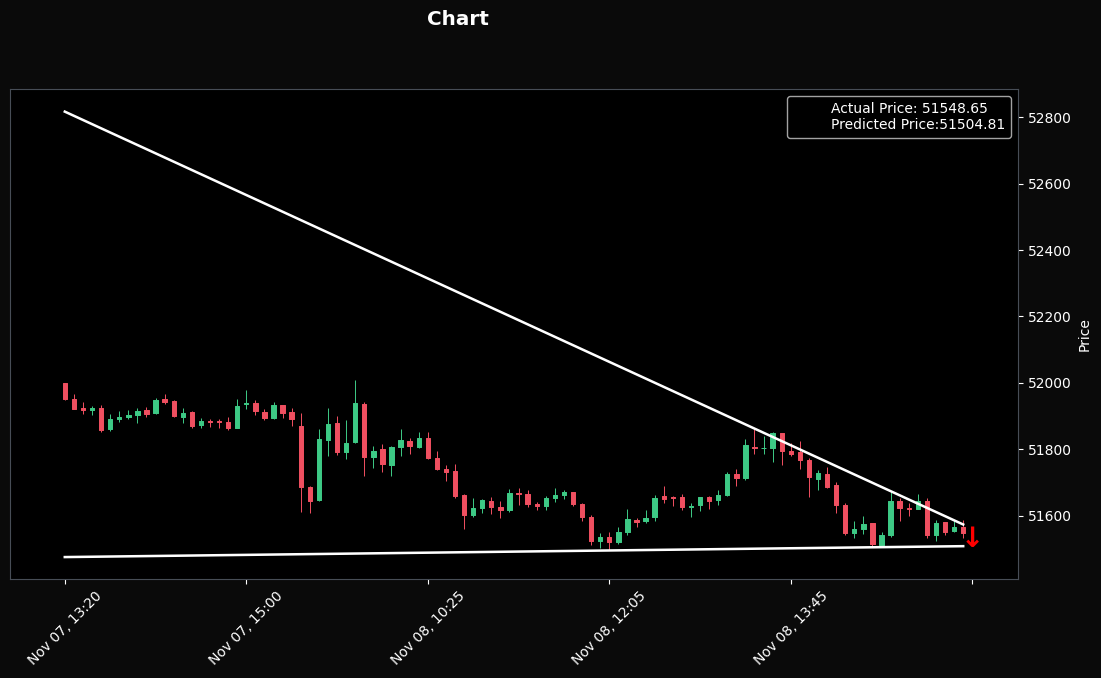

In [176]:
#while True:
clear_output(wait=True)

num_candles = 100

final_df = fetch_and_prepare_final_data()
print(len(final_df))

final_df = final_df.iloc[:-1]

target = final_df['Target'].iloc[-1]

trailing_sl = final_df['Stop Loss'].iloc[-1]

# Identify most recent high and low points
recent_highs, recent_lows = find_local_extrema(final_df)

most_recent_high = recent_highs[-1] if len(recent_highs) > 1 else None
most_recent_low = recent_lows[-1] if len(recent_lows) > 1 else None

high_trendline = [np.nan] * len(final_df)
low_trendline = [np.nan] * len(final_df)

if most_recent_high is not None:
    previous_high = recent_highs[-2] if len(recent_highs) > 2 else most_recent_high
    high_trendline = get_trendline(final_df, previous_high, most_recent_high, kind='high')

if most_recent_low is not None:
    previous_low = recent_lows[-2] if len(recent_lows) > 2 else most_recent_low
    low_trendline = get_trendline(final_df, previous_low, most_recent_low, kind='low')

# Random Forest Classifier Prediction
rf_final_data = final_df[-1:][[col for col in final_df.columns if col != 'Signal']]

rf_final_pred = rf_model.predict(rf_final_data)
rf_final_pred = rf_final_pred[0]

#Scale the final df
scaled_final_df = final_df[-sequence_length:].copy()

for column in scaled_final_df.columns:
    scaled_final_df[column] = regression_scalers[column].transform(scaled_final_df[column].values.reshape(-1, 1))

# To include the most recent data for prediction:
latest_sequence = scaled_final_df.values
latest_sequence = latest_sequence.reshape(1, sequence_length, -1)

# Linear Regression Model Prediction
y_pred_lr_latest = lr_reg_model.predict(latest_sequence.reshape(latest_sequence.shape[0], -1))

# LSTM Model Prediction
y_pred_lstm_latest = lstm_reg_model.predict(latest_sequence)
y_pred_lstm_latest = np.squeeze(y_pred_lstm_latest)

# GRU Model Prediction
y_pred_gru_latest = gru_reg_model.predict(latest_sequence)
y_pred_gru_latest = np.squeeze(y_pred_gru_latest)

# Use the same weights as determined during training
y_pred_ensemble_latest = (weight_lr_reg * y_pred_lr_latest) + (weight_lstm_reg * y_pred_lstm_latest) + (weight_gru_reg * y_pred_gru_latest)

# Inverse transform prediction for Ensemble Model
y_pred_ensemble_latest_original = regression_scalers['close'].inverse_transform(y_pred_ensemble_latest.reshape(-1, 1)).flatten()
y_pred_ensemble_latest_original = round(y_pred_ensemble_latest_original[0], 2)

print(final_df.index[-1])
print(final_df['close'].iloc[-1])
print(y_pred_ensemble_latest_original)
print(rf_final_pred)

# Prepare candlestick data for mplfinance
actual_candles = final_df[-num_candles:].copy()

# Create a DataFrame for mplfinance
mpf_df = actual_candles[['open', 'high', 'low', 'close']]

# Create addplot elements for predicted prices and actual close prices
ap = [
    mpf.make_addplot(final_df['close'][-num_candles:], color='none', panel=0, secondary_y=False, label=f"Actual Price: {final_df['close'].iloc[-1]}\nPredicted Price:{y_pred_ensemble_latest_original}"),
    #mpf.make_addplot(y_pred_ensemble_final_plot, color=(0.95, 0.38, 0.25, 1), panel=0, secondary_y=False, label=f'Predicted Prices ({y_pred_ensemble_final_plot[-1]:.2f})')
]

# Add trendlines to the plot
if most_recent_high is not None:
    ap.append(mpf.make_addplot(high_trendline[-num_candles:], color='white', linestyle='-', panel=0, secondary_y=False))

if most_recent_low is not None:
    ap.append(mpf.make_addplot(low_trendline[-num_candles:], color='white', linestyle='-', panel=0, secondary_y=False))

fig, axlist = mpf.plot(mpf_df, type='candle', style='binancedark', volume=False, addplot=ap,
                        title=f'Chart', ylabel='Price',
                        figsize=(14, 7), returnfig=True)

for ax in axlist:
    ax.grid(False)

# Add the arrow for the future candle closing price
last_closing_price = final_df['close'].iloc[-1]
future_price = y_pred_ensemble_latest_original

if future_price > last_closing_price:
    arrow_text = '↑'
    arrow_color = 'green'
elif future_price < last_closing_price:
    arrow_text = '↓'
    arrow_color = 'red'
else:
    arrow_text = 'x'
    arrow_color = 'white'

axlist[0].annotate(
    arrow_text,
    (len(mpf_df), future_price),
    color=arrow_color,
    fontsize=20,
    fontweight='bold',
    ha='center'
)
axlist[0].legend()

plt.show()

#market_entry_exit_logic(rf_final_pred, final_df['close'].iloc[-1], y_pred_ensemble_latest_original, final_df)

#sleep_time = get_sleep_time(interval_minutes)
#time.sleep(sleep_time)